# Mini Project 3

The code below provides a visual representation of how the Black-Scholes **call option** price changes with respect to time.

**a)** Use the visualization to interpret how the *rate of change* of the Black-Scholes call option price behaves as time progresses.

**b)** Create a separate graphic to visualize how the *rate of change* of the Black-Scholes call option price depends on the spot price $S(0)$.

**c)** Repeat parts **a** and **b** for **put option** prices.

**d)** Use the space below to record your observations and reflections based on the generated plots.

---

### Observations:

- *Call Option – Time Sensitivity: As time to expiry is close, the Black-Scholes Call option price decreases
- *Call Option – Spot Price Sensitivity: As spot price is close to strike price, BS Call price 
- *Put Option – Time Sensitivity: As time to expiry is close, the Black-Scholes Put option price decreases
- *Put Option – Spot Price Sensitivity:*  

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
import seaborn as sns
sns.set_style('darkgrid')
from scipy.differentiate import derivative

def bs_call(S0, K, sigma, t=1, r=0):
    """
    Description:
    
    Computes the Black-Scholes value of a European call option.
    
    Parameters:
        S0: Current asset price
        K: Strike price
        sigma: Yearly standard deviation of log-returns (volatility)
        t: Time to expiration (in years)
        r: Risk-free interest rate
    
    Returns:
        Call option price
    """
    d1 = (np.log(S0/K) + (r+.5*sigma**2)*t)/(sigma*np.sqrt(t))
    #d2 = (np.log(S0/K) + (r-.5*sigma**2)*t)/(sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)
    return S0*norm.cdf(d1)-K*np.exp(-r*t)*norm.cdf(d2)


def bs_put(S0, K, sigma, t=1, r=0):
    """
    Description:
    
    Computes the Black-Scholes value of a European put option.
    
    Parameters:
        S0: Current asset price
        K: Strike price
        sigma: Yearly standard deviation of log-returns (volatility)
        t: Time to expiration (in years)
        r: Risk-free interest rate
    
    Returns:
        Put option price
    """
    
    d1 = (np.log(S0/K) + (r+.5*sigma**2)*t)/(sigma*np.sqrt(t))
    #d2 = (np.log(S0/K) + (r-.5*sigma**2)*t)/(sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)
    return -S0*norm.cdf(-d1)+K*np.exp(-r*t)*norm.cdf(-d2)

[100, 101]
[2.27295765 2.27295765]


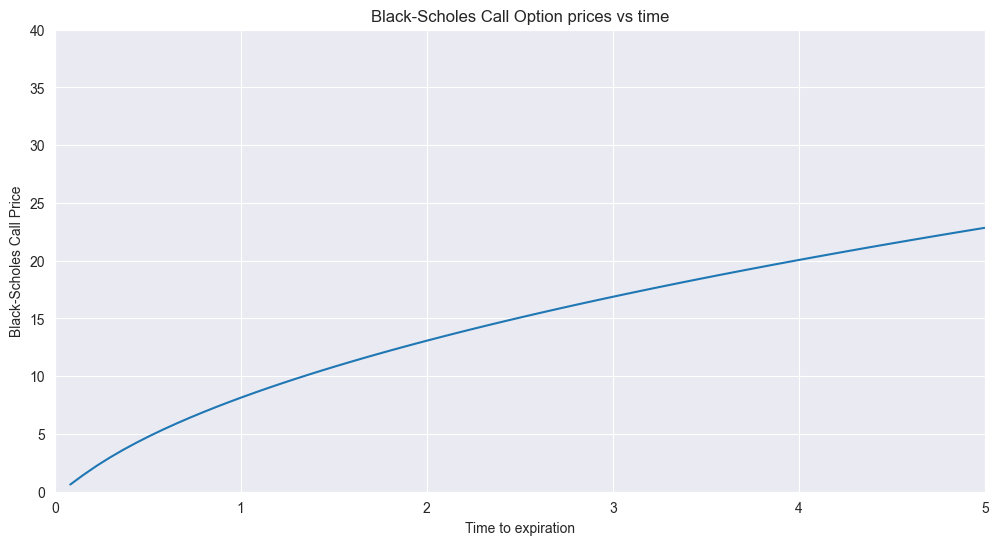

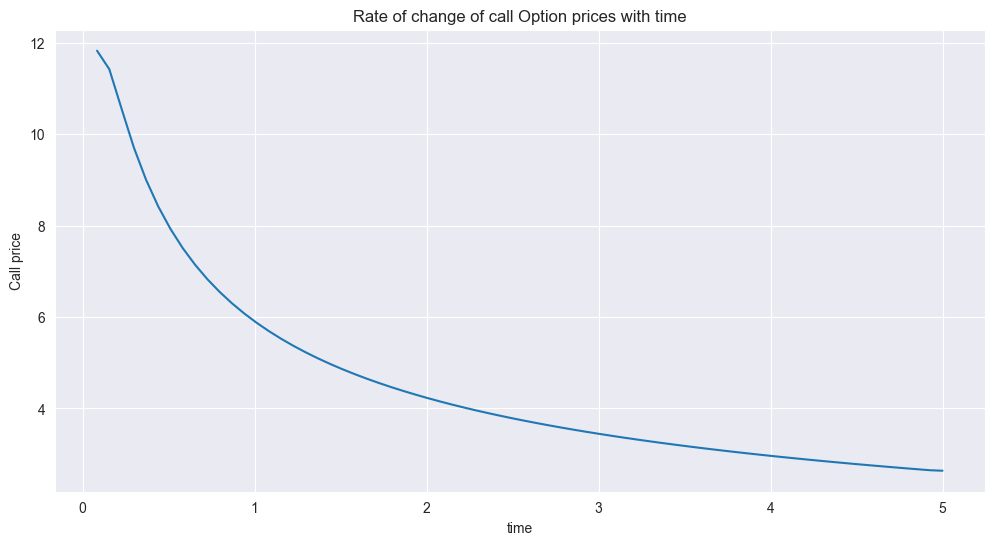

In [ ]:
S0 = 100
K = 110
sigma = .3
times = np.linspace(1/12, 5, 70)

call_prices = [bs_call(S0,K,sigma, t = times[i]) for i in range(len(times))]
call_prices_change_t = np.gradient(call_prices, times)

plt.figure(figsize = (12,6))
plt.title('Black-Scholes Call Option prices vs time')
plt.xlim(0,5)
plt.ylim(0,40)
plt.plot(times, call_prices)
plt.xlabel('Time to expiration')
plt.ylabel('Black-Scholes Call Price')
plt.show()

plt.figure(figsize = (12,6))
plt.title('Rate of change of call Option prices with time')
plt.plot(times, call_prices_change_t)
plt.xlabel('time')
plt.ylabel('Call price')
plt.show()

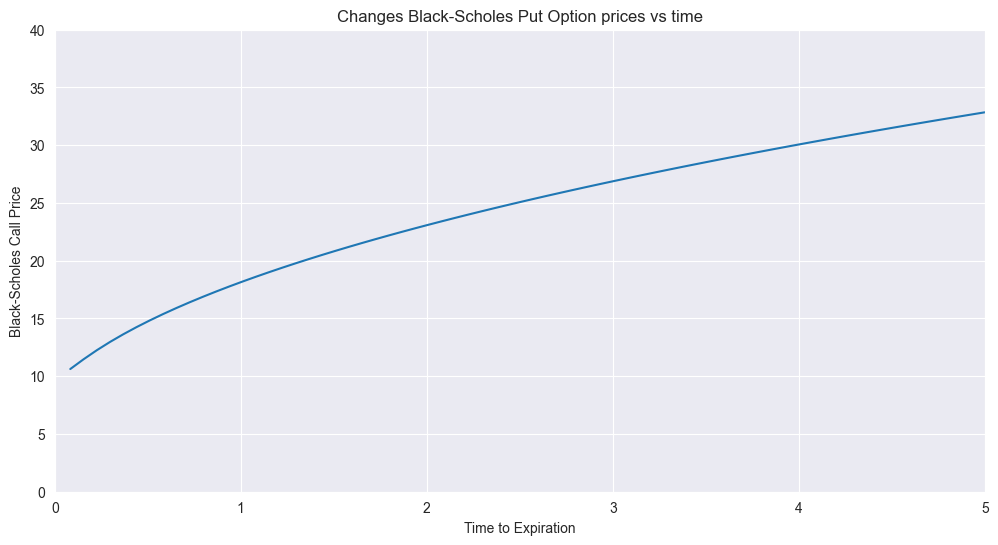

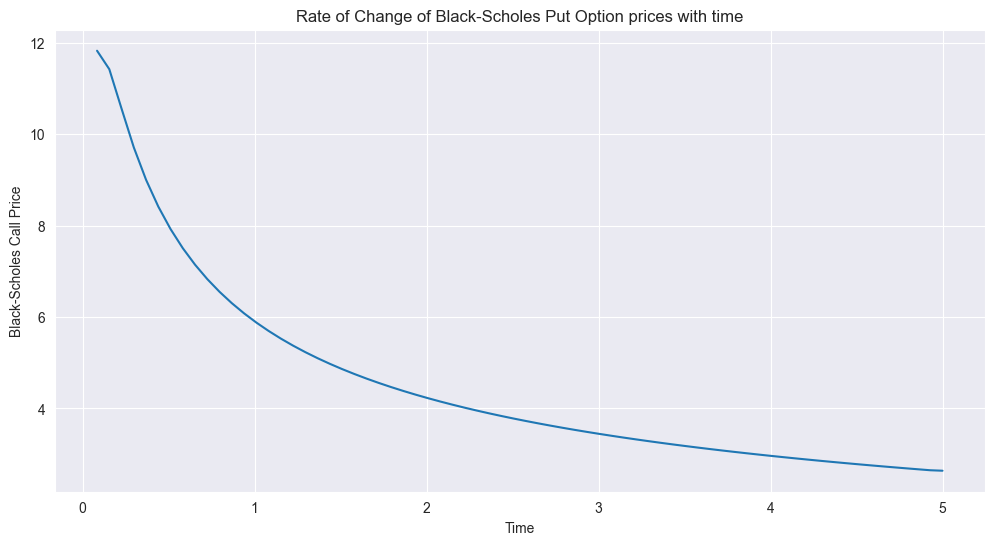

In [29]:
S0 = 100
K = 110
sigma = .3
times = np.linspace(1/12, 5, 70)

put_prices = [bs_put(S0,K,sigma, t = times[i]) for i in range(len(times))]
put_prices_change_t = np.gradient(put_prices, times)

plt.figure(figsize = (12,6))
plt.title('Changes Black-Scholes Put Option prices vs time')
plt.xlim(0,5)
plt.ylim(0,40)
plt.plot(times, put_prices)
plt.xlabel('Time to Expiration')
plt.ylabel('Black-Scholes Call Price')
plt.show()

plt.figure(figsize = (12,6))
plt.title('Rate of Change of Black-Scholes Put Option prices with time')
plt.plot(times, put_prices_change_t)
plt.xlabel('Time')
plt.ylabel('Black-Scholes Call Price')
plt.show()

## Rate of change of call and put option prices with respect to Spot prices

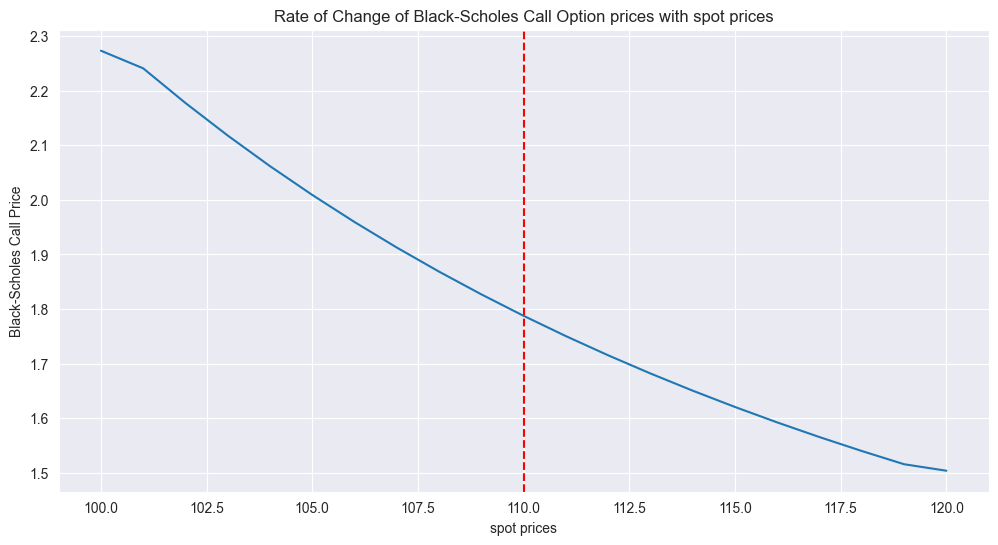

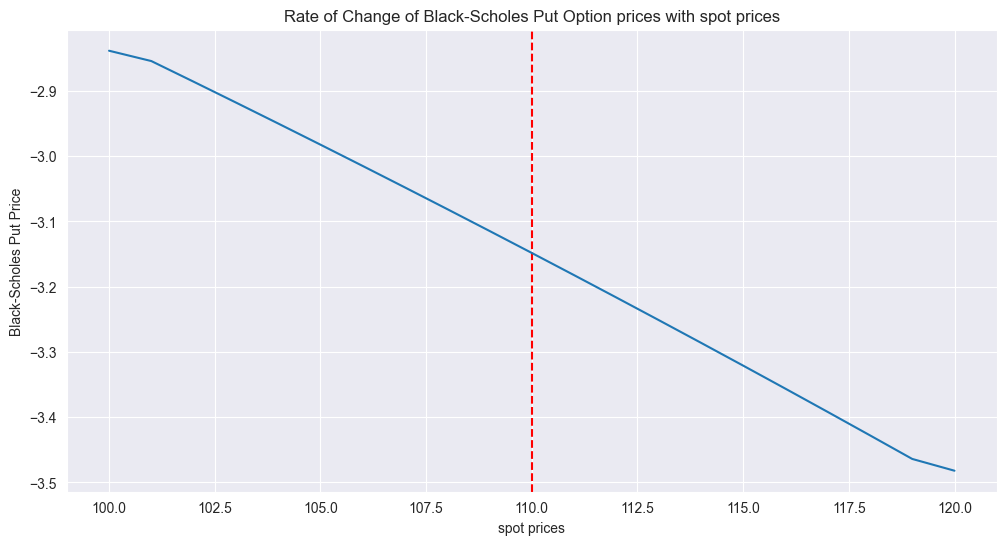

In [81]:
spot_prices = [100+i for i in range(21)]
call_prices_spot = [bs_call(S, K, 0.3, t = 1) for S in spot_prices]
put_prices_spot = [bs_put(S,K,sigma, t = 10) for S in spot_prices]

call_prices_change_spotprice = np.gradient(spot_prices,call_prices_spot)

put_prices_change_spotprice = np.gradient(spot_prices,put_prices_spot)

plt.figure(figsize = (12,6))
plt.title('Rate of Change of Black-Scholes Call Option prices with spot prices')
plt.axvline(K, label = f'Strike Price', ls = '--', color = 'red')
plt.plot(spot_prices, call_prices_change_spotprice)
plt.xlabel('spot prices')
plt.ylabel('Black-Scholes Call Price')
plt.show()

plt.figure(figsize = (12,6))
plt.title('Rate of Change of Black-Scholes Put Option prices with spot prices')
plt.axvline(K, label = f'Strike Price', ls = '--', color = 'red')
plt.plot(spot_prices, put_prices_change_spotprice)
plt.xlabel('spot prices')
plt.ylabel('Black-Scholes Put Price')
plt.show()